In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,roc_curve,confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

import xgboost as xgb
import shap
import joblib
import warnings
warnings.filterwarnings('ignore',category=FutureWarning)

In [ ]:
df = pd.read_csv("customer_purchase_data.csv")

In [ ]:
df.head()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


In [ ]:
df["DiscountsAvailed"].value_counts()

,count
DiscountsAvailed,
3,265
5,258
4,258
1,242
0,240
2,237


In [ ]:
df.shape

(1500, 9)

In [ ]:
df.columns

Index(['Age', 'Gender', 'AnnualIncome', 'NumberOfPurchases', 'ProductCategory',
       'TimeSpentOnWebsite', 'LoyaltyProgram', 'DiscountsAvailed',
       'PurchaseStatus'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB


In [ ]:
df.describe()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,44.298667,0.504667,84249.164338,10.420000,2.012667,30.469040,0.326667,2.555333,0.43200
std,15.537259,0.500145,37629.493078,5.887391,1.428005,16.984392,0.469151,1.705152,0.49552
min,18.000000,0.000000,20001.512518,0.000000,0.000000,1.037023,0.000000,0.000000,0.00000
25%,31.000000,0.000000,53028.979155,5.000000,1.000000,16.156700,0.000000,1.000000,0.00000
50%,45.000000,1.000000,83699.581476,11.000000,2.000000,30.939516,0.000000,3.000000,0.00000
75%,57.000000,1.000000,117167.772858,15.000000,3.000000,44.369863,1.000000,4.000000,1.00000
max,70.000000,1.000000,149785.176481,20.000000,4.000000,59.991105,1.000000,5.000000,1.00000


# **Handle Missing Values**

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
AnnualIncome,0
NumberOfPurchases,0
ProductCategory,0
TimeSpentOnWebsite,0
LoyaltyProgram,0
DiscountsAvailed,0
PurchaseStatus,0


# **Outlier Detection**

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
outlier_summary = {}

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary[col] = len(outliers)

# Display number of outliers in each column
outlier_df = pd.DataFrame((outlier_summary.items()), columns=['Feature','Number_of_Outliers'])
outlier_df

,Feature,Number_of_Outliers
0,Age,0
1,Gender,0
2,AnnualIncome,0
3,NumberOfPurchases,0
4,ProductCategory,0
5,TimeSpentOnWebsite,0
6,LoyaltyProgram,0
7,DiscountsAvailed,0
8,PurchaseStatus,0


                         Age    Gender  AnnualIncome  NumberOfPurchases  \
Age                 1.000000  0.022055      0.016438          -0.038778   
Gender              0.022055  1.000000      0.010054           0.001373   
AnnualIncome        0.016438  0.010054      1.000000           0.000276   
NumberOfPurchases  -0.038778  0.001373      0.000276           1.000000   
ProductCategory    -0.020767 -0.028572      0.032163           0.006270   
TimeSpentOnWebsite  0.032309  0.012814     -0.001505           0.024644   
LoyaltyProgram     -0.005980  0.033302     -0.045296           0.055358   
DiscountsAvailed    0.004009 -0.056624      0.016393           0.029581   
PurchaseStatus     -0.255747  0.002627      0.188214           0.222691   

                    ProductCategory  TimeSpentOnWebsite  LoyaltyProgram  \
Age                       -0.020767            0.032309       -0.005980   
Gender                    -0.028572            0.012814        0.033302   
AnnualIncome            

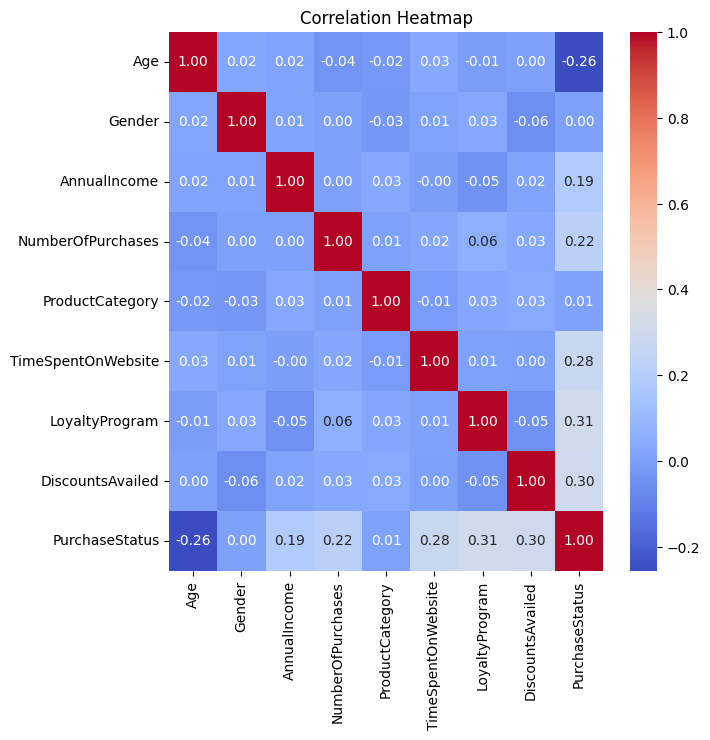

In [ ]:
plt.figure(figsize=(7,7))

corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()


Target distribution:
 PurchaseStatus
0    0.568
1    0.432
Name: proportion, dtype: float64


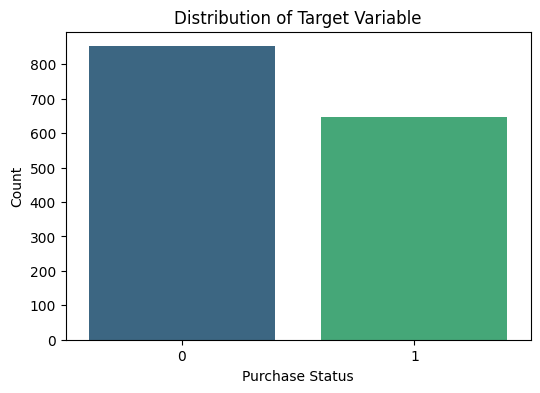

In [ ]:
print("Target distribution:\n", df['PurchaseStatus'].value_counts(normalize=True))
plt.figure(figsize=(6,4))

sns.countplot(x='PurchaseStatus', data=df,palette='viridis')

plt.title("Distribution of Target Variable")
plt.xlabel("Purchase Status")
plt.ylabel("Count")

plt.show()

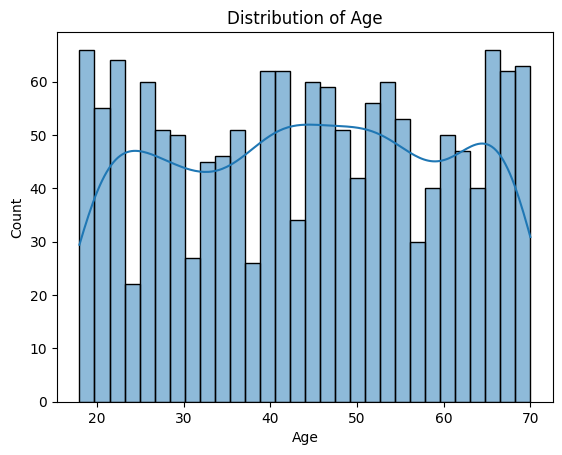

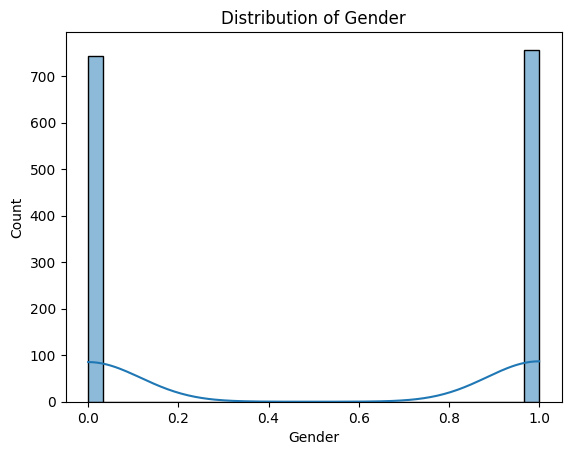

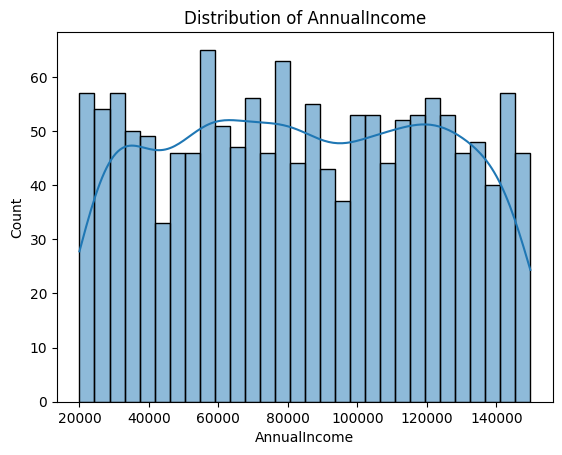

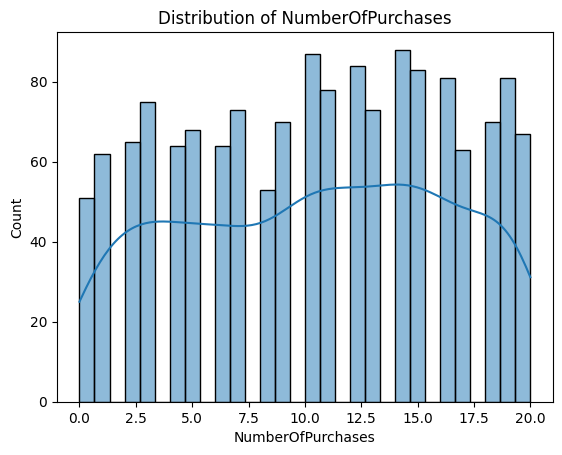

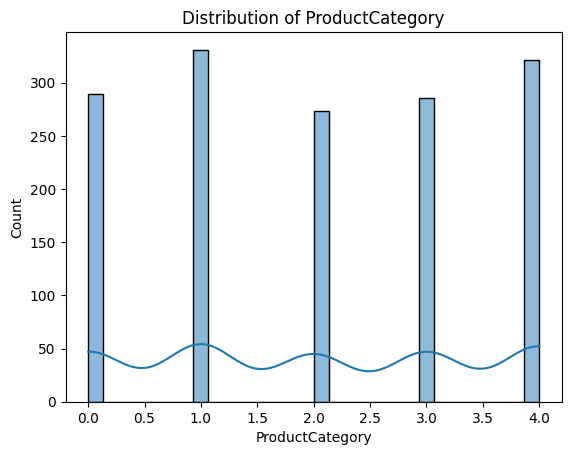

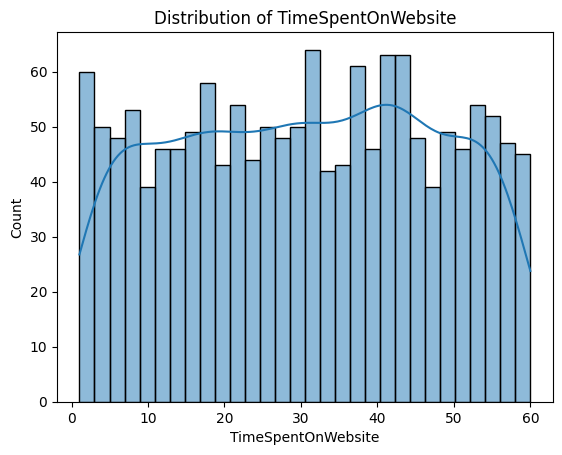

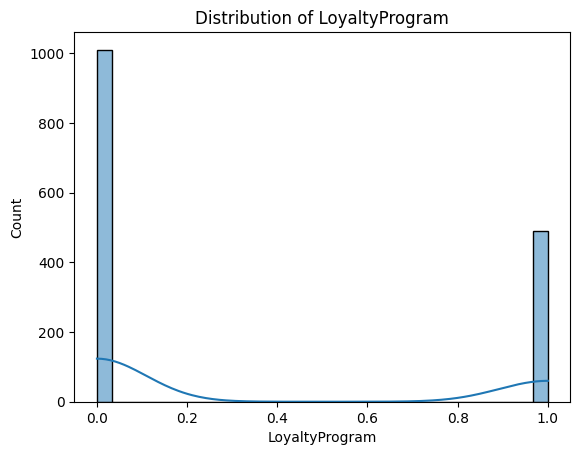

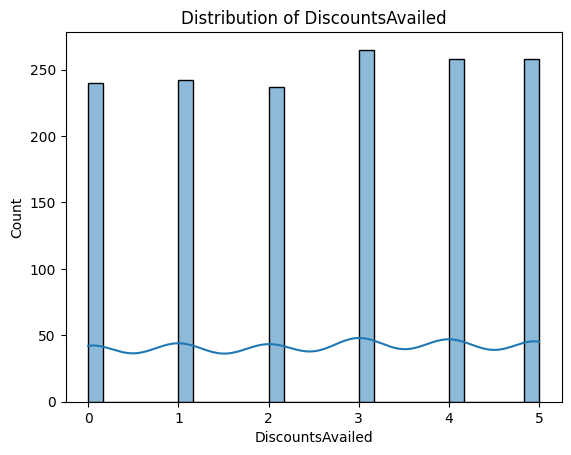

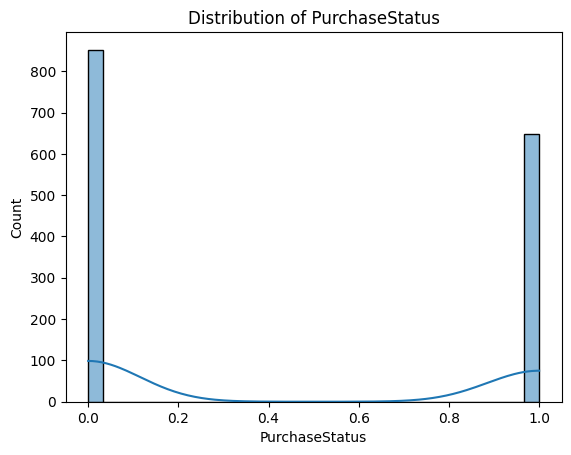

In [ ]:
# --- B) Numeric distributions ---
for col in numeric_cols:  # show first 5
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title("Distribution of {}".format(col))
    plt.show()


In [ ]:
label_encoder = LabelEncoder()

if df['ProductCategory'].dtype == 'object':
    df['ProductCategory'] = label_encoder.fit_transform(df['ProductCategory'])

# **Feature Engineering**

In [ ]:
# Engagement Score
df['EngagementScore'] = (
    0.5 * df['TimeSpentOnWebsite'] +
    0.3 * df['NumberOfPurchases'] +
    0.2 * df['DiscountsAvailed']
)

In [ ]:
# Recency-Frequency Indicator
df['RecencyFrequency'] = df['NumberOfPurchases'] / (df['TimeSpentOnWebsite'] + 1)

In [ ]:
# Customer Activity Index
df['CustomerActivityIndex'] = (
    df['NumberOfPurchases'] * df['TimeSpentOnWebsite']
)

In [ ]:
# Income Level Binning
df['IncomeLevel'] = pd.qcut(df['AnnualIncome'], 3, labels=[0,1,2])

# **Feature and Target Split**

In [ ]:
X = df.drop('PurchaseStatus', axis=1)
y = df['PurchaseStatus']

In [ ]:
X.columns

Index(['Age', 'Gender', 'AnnualIncome', 'NumberOfPurchases', 'ProductCategory',
       'TimeSpentOnWebsite', 'LoyaltyProgram', 'DiscountsAvailed',
       'EngagementScore', 'RecencyFrequency', 'CustomerActivityIndex',
       'IncomeLevel'],
      dtype='object')

In [ ]:
pd.qcut(df['AnnualIncome'], 3, labels=[0,1,2])

,AnnualIncome
0,1
1,0
2,2
3,2
4,1
...,...
1495,1
1496,0
1497,0
1498,2


# **Train Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# **Standardization**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
# Prediction
y_pred_log = log_model.predict(X_test_scaled)
y_train_pred= log_model.predict(X_train_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
print("Accuracy TRAIN:", accuracy_score(y_train,y_train_pred))
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))

Accuracy TRAIN: 0.8141666666666667
Accuracy: 0.84
Precision: 0.8773584905660378
Recall: 0.7265625
F1 Score: 0.7948717948717948
ROC AUC Score: 0.8948946220930233
Confusion Matrix:
 [[159  13]
 [ 35  93]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.87       172
           1       0.88      0.73      0.79       128

    accuracy                           0.84       300
   macro avg       0.85      0.83      0.83       300
weighted avg       0.84      0.84      0.84       300



In [ ]:
param_grid = {
    "C": [0.01, 0.1, 1, 10]
}
log_grid = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

log_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10]}, scoring='f1')

In [ ]:

print("Best Parameters", log_grid.best_params_)
print("Best CV score:", log_grid.best_score_)
best_log = log_grid.best_estimator_
# Prediction
y_train_predgrid= best_log.predict(X_train_scaled)
y_pred_loggrid= best_log.predict(X_test_scaled)
y_prob_loggrid= best_log.predict_proba(X_test_scaled)[:,1]

Best Parameters {'C': 10}
Best CV score: 0.7826361362046963


In [ ]:
print("Accuracy TRAIN:", accuracy_score(y_train,y_train_predgrid))
print("Accuracy:", accuracy_score(y_test, y_pred_loggrid))
print("Precision:", precision_score(y_test, y_pred_loggrid))
print("Recall:", recall_score(y_test, y_pred_loggrid))
print("F1 Score:", f1_score(y_test, y_pred_loggrid))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_loggrid))



Accuracy TRAIN: 0.8133333333333334
Accuracy: 0.8433333333333334
Precision: 0.8785046728971962
Recall: 0.734375
F1 Score: 0.8
ROC AUC Score: 0.8949854651162791


In [ ]:
log_grid_confu=confusion_matrix(y_test, y_pred_loggrid)
log_grid_class=classification_report(y_test, y_pred_loggrid)
print(log_grid_confu)
print(log_grid_class)

[[159  13]
 [ 34  94]]
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       172
           1       0.88      0.73      0.80       128

    accuracy                           0.84       300
   macro avg       0.85      0.83      0.84       300
weighted avg       0.85      0.84      0.84       300



# **Compare with differnet Models,**

# Train and Predict all models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "SVM": LinearSVC(),
    "XGBoost": xgb.XGBClassifier(n_estimators=200, random_state=42),
    "Naive Bayes": GaussianNB()
}
results = []
for name,model in models.items():
  model.fit(X_train_scaled, y_train)
  y_test_pred =model.predict(X_test_scaled)
  y_train_pred= log_model.predict(X_train_scaled)
  train_acc = accuracy_score(y_train, y_train_pred)
  test_acc = accuracy_score(y_test, y_test_pred)
  precision = precision_score(y_test, y_test_pred)
  recall = recall_score(y_test, y_test_pred)
  f1 = f1_score(y_test, y_test_pred)
  roc_auc = roc_auc_score(y_test, y_test_pred)
  results.append({"Model": name,
      "train accuracy": train_acc,
      "Test Accuracy": test_acc,
      "Precision": precision,
      "Recall": recall,
      "F1 Score": f1,
      "ROC AUC Score": roc_auc
                  })
results_df = pd.DataFrame(results)
results_df






,Model,train accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC Score
0,Logistic Regression,0.814167,0.840000,0.877358,0.726562,0.794872,0.825491
1,KNN,0.814167,0.840000,0.892157,0.710938,0.791304,0.823492
2,Decision Tree,0.814167,0.856667,0.851240,0.804688,0.827309,0.850018
3,Random Forest,0.814167,0.943333,0.974359,0.890625,0.930612,0.936592
4,Gradient Boosting,0.814167,0.926667,0.941667,0.882812,0.911290,0.921057
5,SVM,0.814167,0.833333,0.875000,0.710938,0.784483,0.817678
6,XGBoost,0.814167,0.930000,0.957265,0.875000,0.914286,0.922965
7,Naive Bayes,0.814167,0.763333,0.720930,0.726562,0.723735,0.758630


In [ ]:
results_df.sort_values(by=["F1 Score","Test Accuracy"],ascending=False,inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df


,Model,train accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC Score
0,Random Forest,0.814167,0.943333,0.974359,0.890625,0.930612,0.936592
1,XGBoost,0.814167,0.930000,0.957265,0.875000,0.914286,0.922965
2,Gradient Boosting,0.814167,0.926667,0.941667,0.882812,0.911290,0.921057
3,Decision Tree,0.814167,0.856667,0.851240,0.804688,0.827309,0.850018
4,Logistic Regression,0.814167,0.840000,0.877358,0.726562,0.794872,0.825491
5,KNN,0.814167,0.840000,0.892157,0.710938,0.791304,0.823492
6,SVM,0.814167,0.833333,0.875000,0.710938,0.784483,0.817678
7,Naive Bayes,0.814167,0.763333,0.720930,0.726562,0.723735,0.758630


In [ ]:
model=RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1)
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3,5,8,10,20]
}
rf_grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_
# Prediction
y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:,1]


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))
#rf_confu=confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:\n",confusion_matrix(y_test, y_pred_rf))
#rf_class=classification_report(y_test, y_pred_rf)
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


Accuracy: 0.9433333333333334
Precision: 0.9743589743589743
Recall: 0.890625
F1 Score: 0.9306122448979591
ROC AUC Score: 0.9567360101744187

Confusion Matrix:
 [[169   3]
 [ 14 114]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       172
           1       0.97      0.89      0.93       128

    accuracy                           0.94       300
   macro avg       0.95      0.94      0.94       300
weighted avg       0.95      0.94      0.94       300



In [ ]:
gbmodel=GradientBoostingClassifier(n_estimators=200,random_state=42)
param_grid = {
    "n_estimators": [100, 200,300],
    "learning_rate": [0.01, 0.1, 0.2]
}
gb_grid = GridSearchCV(
    estimator=gbmodel,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

gb_grid.fit(X_train_scaled, y_train)
best_gb = gb_grid.best_estimator_
# Prediction
y_pred_gb = best_gb.predict(X_test_scaled)
y_prob_gb = best_gb.predict_proba(X_test_scaled)[:,1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_gb))
#gb_confu=confusion_matrix(y_test, y_pred_gb)
print("\nConfusion Matrix:\n",confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report:\n",classification_report(y_test, y_pred_gb))


Accuracy: 0.94
Precision: 0.9661016949152542
Recall: 0.890625
F1 Score: 0.926829268292683
ROC AUC Score: 0.9496048328488372

Confusion Matrix:
 [[168   4]
 [ 14 114]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       172
           1       0.97      0.89      0.93       128

    accuracy                           0.94       300
   macro avg       0.94      0.93      0.94       300
weighted avg       0.94      0.94      0.94       300



In [ ]:
xgbmodel=xgb.XGBClassifier(n_estimators=200,random_state=42)
param_grid = {
    "n_estimators": [100,200,300],
    "learning_rate": [0.01, 0.05, 0.1,0.2]}

xgb_grid = GridSearchCV(
    estimator=xgbmodel,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, y_train)
best_xgb = xgb_grid.best_estimator_
# Prediction
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)[:,1]


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_xgb))


Accuracy: 0.9533333333333334
Precision: 0.9830508474576272
Recall: 0.90625
F1 Score: 0.943089430894309
Confusion Matrix:
 [[170   2]
 [ 12 116]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96       172
           1       0.98      0.91      0.94       128

    accuracy                           0.95       300
   macro avg       0.96      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300

ROC AUC Score: 0.9558502906976745


# **ROC Curve Comparison**

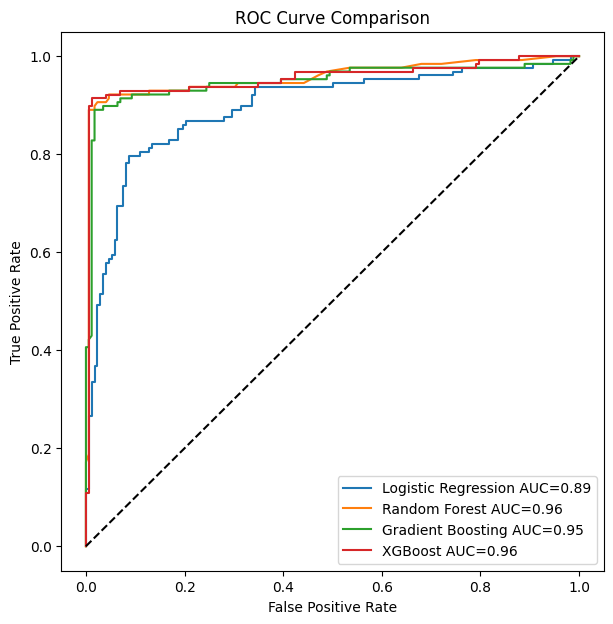

In [ ]:
fpr,tpr,thresholds=roc_curve(y_test,y_prob_log)
aucscore_log=roc_auc_score(y_test,y_prob_log)

fpr1,tpr1,thresholds1=roc_curve(y_test,y_prob_rf)
aucscore_rf=roc_auc_score(y_test,y_prob_rf)

fpr2,tpr2,thresholds2=roc_curve(y_test,y_prob_gb)
aucscore_gb=roc_auc_score(y_test,y_prob_gb)

fpr3,tpr3,thresholds3=roc_curve(y_test,y_prob_xgb)
aucscore_xgb=roc_auc_score(y_test,y_prob_xgb)

plt.figure(figsize=(7,7))
plt.plot(fpr,tpr,label="Logistic Regression AUC={}".format(aucscore_log.round(2)))
plt.plot(fpr1,tpr1,label="Random Forest AUC={}".format(aucscore_rf.round(2)))
plt.plot(fpr2,tpr2,label="Gradient Boosting AUC={}".format(aucscore_gb.round(2)))
plt.plot(fpr3,tpr3,label="XGBoost AUC={}".format(aucscore_xgb.round(2)))
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


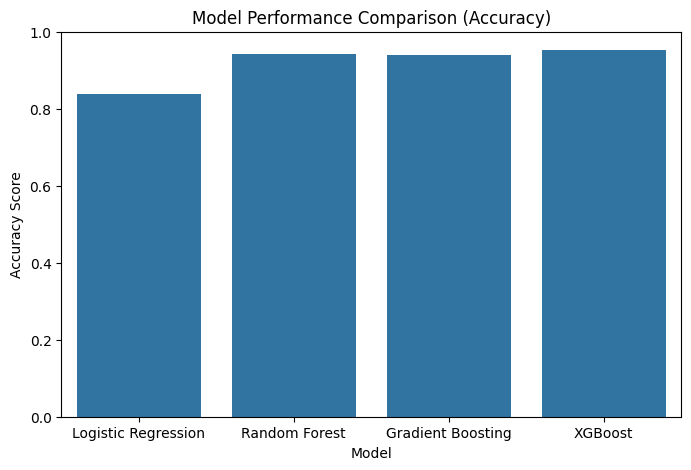

In [ ]:
model_names = ['Logistic Regression','Random Forest','Gradient Boosting','XGBoost']

accuracies = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_gb),
    accuracy_score(y_test, y_pred_xgb)
]

results_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

plt.figure(figsize=(8,5))

sns.barplot(data=results_df, x='Model', y='Accuracy')

plt.title("Model Performance Comparison (Accuracy)")
plt.ylabel("Accuracy Score")
#plt.xticks(rotation=20)

plt.show()

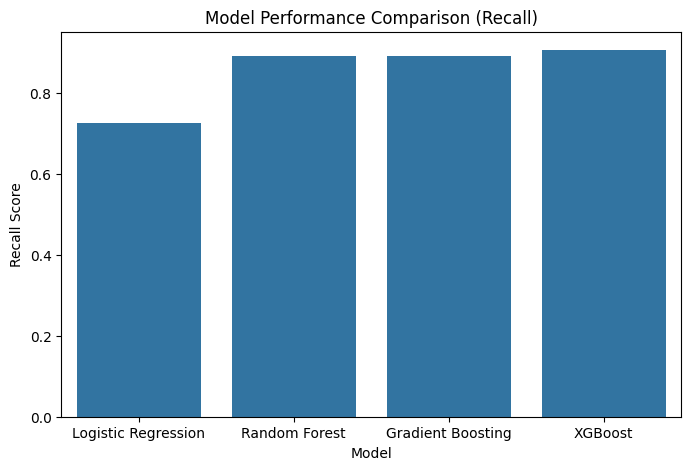

In [ ]:
model_names = ['Logistic Regression','Random Forest','Gradient Boosting','XGBoost']

recalls = [
    recall_score(y_test, y_pred_log),
    recall_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_gb),
    recall_score(y_test, y_pred_xgb)
]

results_df1 = pd.DataFrame({
    'Model': model_names,
    'Recall': recalls
})

plt.figure(figsize=(8,5))

sns.barplot(data=results_df1, x='Model', y='Recall')

plt.title("Model Performance Comparison (Recall)")
plt.ylabel("Recall Score")


plt.show()

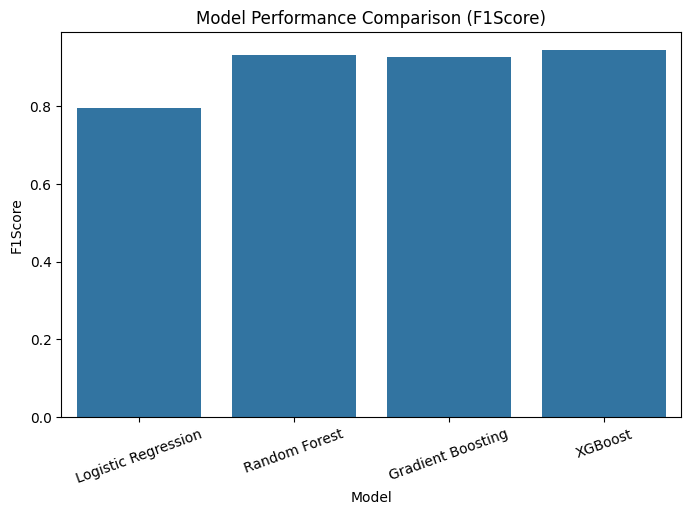

In [ ]:
model_names = ['Logistic Regression','Random Forest','Gradient Boosting','XGBoost']

f1scores = [
    f1_score(y_test, y_pred_log),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_gb),
    f1_score(y_test, y_pred_xgb)
]

results_df2 = pd.DataFrame({
    'Model': model_names,
    'F1 Score': f1scores

})

results_df = pd.DataFrame({
    'Model': model_names,
    'F1Score': f1scores
})

plt.figure(figsize=(8,5))

sns.barplot(data=results_df, x='Model', y='F1Score')

plt.title("Model Performance Comparison (F1Score)")
plt.ylabel("F1Score")
plt.xticks(rotation=20)

plt.show()

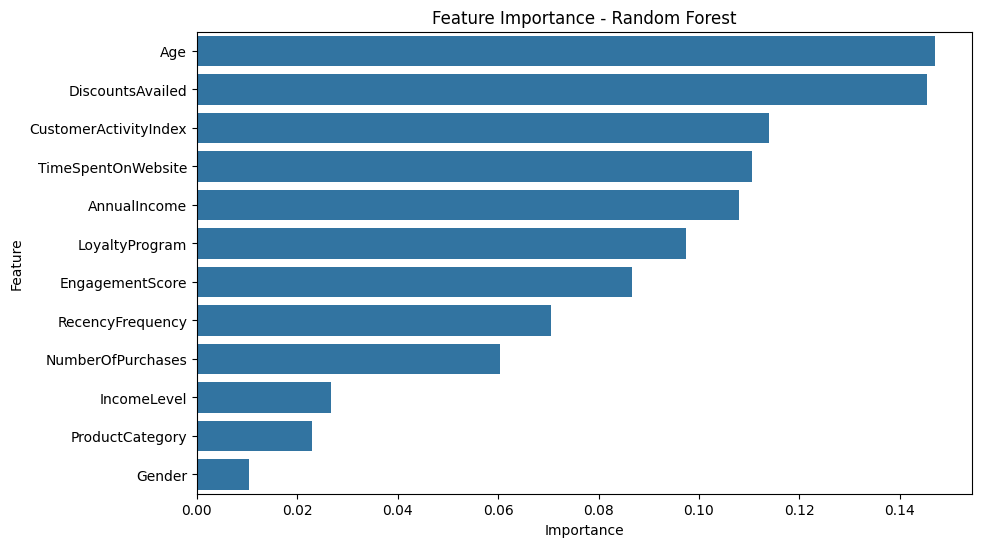

In [ ]:
importances = best_rf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')

plt.title("Feature Importance - Random Forest")
plt.show()

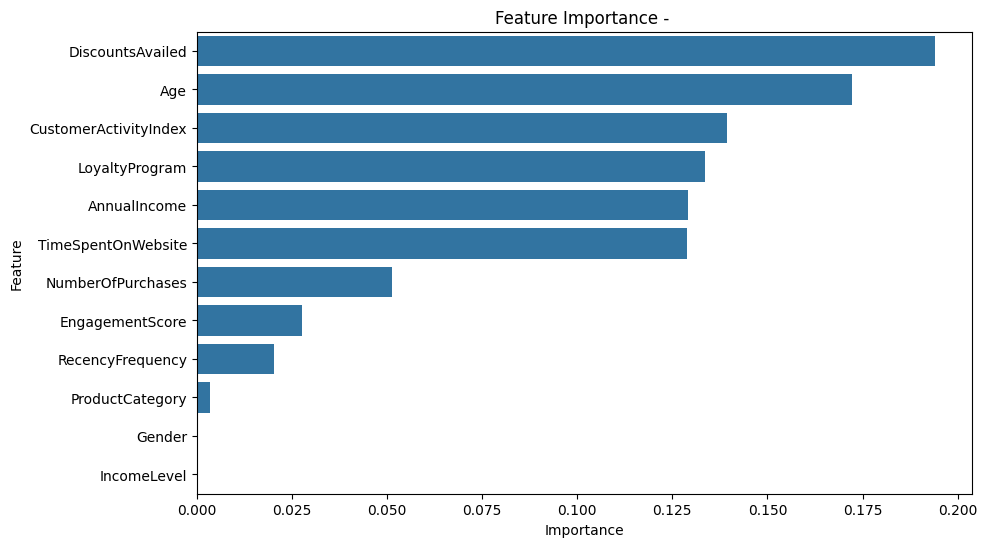

In [ ]:
importances = best_gb.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')

plt.title("Feature Importance - ")
plt.show()

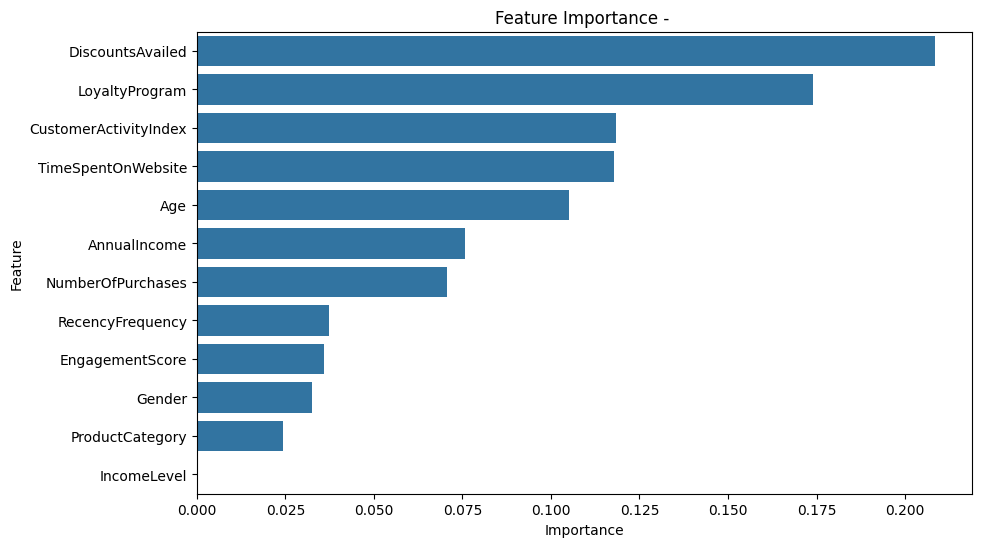

In [ ]:
importances = best_xgb.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')

plt.title("Feature Importance - ")
plt.show()

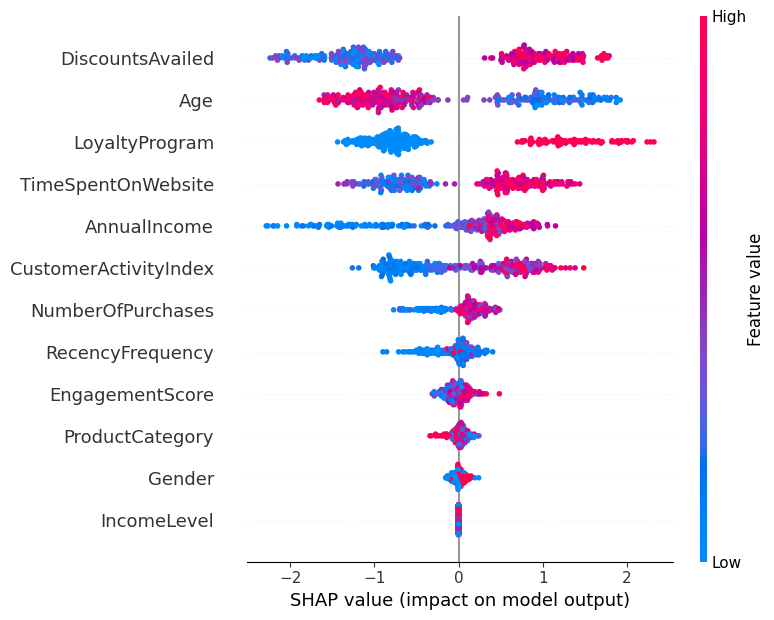

In [ ]:
# Create explainer
explainer = shap.TreeExplainer(best_xgb)
# Calculate SHAP values
shap_values = explainer.shap_values(X_test_scaled)
# Summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

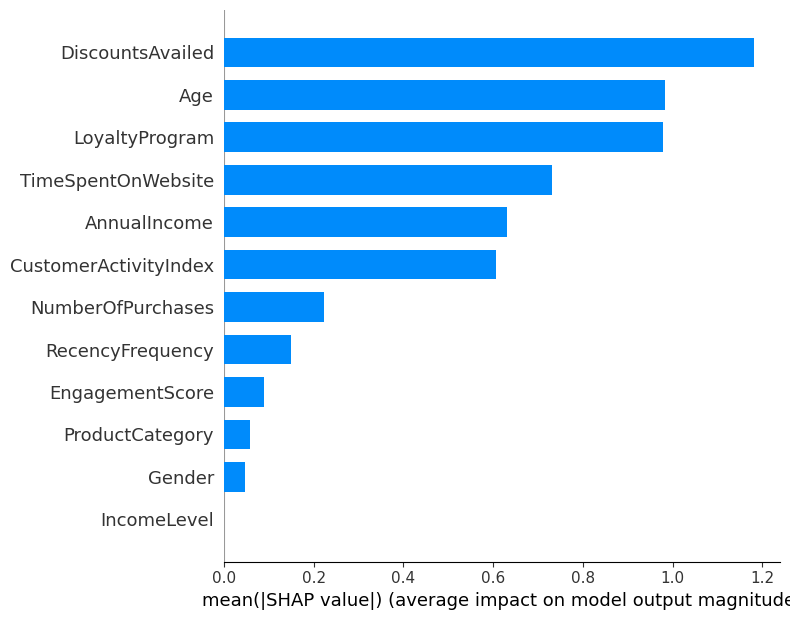

In [ ]:
# Create explainer
explainer = shap.TreeExplainer(best_xgb)
# Calculate SHAP values
shap_values = explainer.shap_values(X_test_scaled)
# Summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, plot_type="bar")

In [ ]:

joblib.dump(best_xgb, "purchase_model_xgb.pkl")


['purchase_model_rf.pkl']

In [ ]:
from google.colab import files
files.download("purchase_model_xgb.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>